### Extracción de caracteristicas con modelos preentrenados

Se busca entrenar un árbol para clasificar las imágenes de MNIST. Para ello se representarán numéricamente las imágenes utilizando la base convolucional de un modelo preentrenado.

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.datasets import fashion_mnist, mnist
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.image import resize

import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# Cargar datos de MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()  #fashion_mnist.load_data()

# Reducir el conjunto de entrenamiento y prueba de manera estratificada
train_size = 0.1  # Proporción del conjunto de entrenamiento
test_size = 0.1   # Proporción del conjunto de prueba

# Dividir entrenamiento (estratificado)
x_train_reduced, _, y_train_reduced, _ = train_test_split(
    x_train, y_train, train_size=train_size, stratify=y_train, random_state=42
)

# Dividir testeo (estratificado)
x_test_reduced, _, y_test_reduced, _ = train_test_split(
    x_test, y_test, train_size=test_size, stratify=y_test, random_state=42
)

print("Tamaño reducido de entrenamiento:", x_train_reduced.shape[0])
print("Tamaño reducido de prueba:", x_test_reduced.shape[0])

x_train = x_train_reduced
y_train = y_train_reduced
x_test = x_test_reduced
y_test = y_test_reduced


# Inspeccionar las dimensiones de los datos
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

Tamaño reducido de entrenamiento: 6000
Tamaño reducido de prueba: 1000
x_train shape: (6000, 28, 28)
y_train shape: (6000,)
x_test shape: (1000, 28, 28)
y_test shape: (1000,)


In [3]:
x_train = np.stack([x_train] * 3, axis=-1) / 255.0  # Convertir a 3 canales
x_test = np.stack([x_test] * 3, axis=-1) / 255.0
x_train = resize(x_train, (96, 96))  # Redimensionar a 96x96 para MobileNetV2
x_test = resize(x_test, (96, 96))

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (6000, 96, 96, 3)
x_test shape: (1000, 96, 96, 3)


In [4]:
# Cargar la base convolucional de MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Contar el número de capas
print(f"Total de capas en MobileNetV2: {len(base_model.layers)}")

Total de capas en MobileNetV2: 154


In [5]:
# Crear un modelo para extraer características
inputs = Input(shape=(96, 96, 3))
features = base_model(inputs)
feature_extractor = Model(inputs, features)

feature_extractor.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         
                                                                 
 mobilenetv2_1.00_96 (Functi  (None, 3, 3, 1280)       2257984   
 onal)                                                           
                                                                 
Total params: 2,257,984
Trainable params: 2,223,872
Non-trainable params: 34,112
_________________________________________________________________


In [6]:
train_features = feature_extractor.predict(x_train, batch_size=64, verbose=1)
test_features = feature_extractor.predict(x_test, batch_size=64, verbose=1)

# Aplanar los mapas de características (Global Average Pooling)
train_features = tf.keras.layers.GlobalAveragePooling2D()(train_features).numpy()
test_features = tf.keras.layers.GlobalAveragePooling2D()(test_features).numpy()

print("Shape de características extraídas:")
print("Train:", train_features.shape, " Test:", test_features.shape)


16/16 [==============================] - 5s 276ms/step
Shape de características extraídas:
Train: (6000, 1280)  Test: (1000, 1280)


### Clasificación usando un árbol

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Entrenar un árbol de decisión con las características extraídas
clf = DecisionTreeClassifier()
clf.fit(train_features, y_train)


DecisionTreeClassifier()

**Resultado de la clasificación usando un árbol**

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

# Predecir sobre el conjunto de prueba
y_pred = clf.predict(test_features)

# Evaluar la precisión
print("Accuracy con Árbol de Decisión:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(cm)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy con Árbol de Decisión: 0.761

Matriz de confusión:
[[ 87   0   0   3   0   1   4   1   1   1]
 [  0 110   0   0   2   1   0   0   1   0]
 [  1   1  64   6   3   9   6   3   6   4]
 [  3   0   3  73   1  14   2   3   2   0]
 [  0   1   4   2  77   3   1   4   2   4]
 [  2   0   6  18   0  55   3   3   1   1]
 [  1   1   6   2   1   1  80   0   4   0]
 [  1   2   6   0   8   1   2  77   3   3]
 [  1   0   5   6   3   6   8   2  64   2]
 [  3   0   2   0   6   1   2   5   8  74]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88        98
           1       0.96      0.96      0.96       114
           2       0.67      0.62      0.64       103
           3       0.66      0.72      0.69       101
           4       0.76      0.79      0.77        98
           5       0.60      0.62      0.61        89
           6       0.74      0.83      0.78        96
           7       0.79      0.75      0.77      

### Agrupamiento con k-means

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score

# Aplicar K-means con 10 clusters (Fashion MNIST tiene 10 clases)
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(train_features)

# Evaluar la calidad del agrupamiento (opcional)
nmi = normalized_mutual_info_score(y_train, kmeans.labels_)
print("Normalized Mutual Information (NMI):", nmi)

Normalized Mutual Information (NMI): 0.6742204013228005


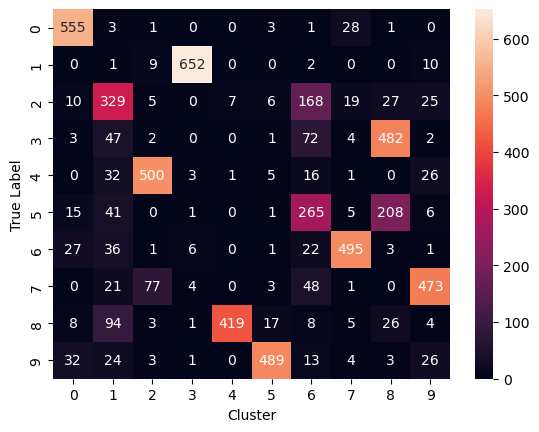

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

clases_x_cluster = confusion_matrix(y_train, kmeans.labels_)
sns.heatmap(clases_x_cluster, annot=True, fmt="d")
plt.xlabel('Cluster')
plt.ylabel('True Label')
plt.show()
